<a href="https://colab.research.google.com/github/AdwaiT-ctrl/NN-programming-tutorials/blob/main/Programming_Tutorial_9_Dense_Predictions_on_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programming Tutorial 9: Dense Predictions on Images

```
Course: CSCI 4922/5922 Spring 2026, University of Colorado Boulder
TA: Everley Tseng
Email: Yu-Yun.Tseng@colorado.edu
* AI assistant was used in making this tutorial
```

## Overview

Sections:
- Pre-trained models
  - Semantic segmentation (FCN)
  - Object detection (Faster R-CNN)
  - Instance segmentation (Mask R-CNN)
- Hands-on simple R-CNN

Objectives:
- Learn how to load pre-trained dense prediction models
- Learn how to build dense prediction models using pre-trained CNN backbones

Today, we will be using the GPUs for efficiency. Before running the script, make sure your runtime is switched to T4 GPU (or higher). A CPU runtime also works for this script, but please expect a much longer time for running.

In [ ]:
import os, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fnn

Load and print the device:

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


## Pre-trained Dense Prediction Models

In this section, we will explore the PyTorch built-in models, FCN, Faster R-CNN, and Mask R-CNN.

Below are the steps we will practice for our examples:

1. Scope the task:
   - Know what the model input is
   - Know what the model output is

2. Review the documentation:
   - Select a pretrained model matching the task input/output constraints

3. Run the sample code:
   - If available, adopt the sample code from the documentation
   - Apply the select architecture and its parameters to your input data and print/plot results

4. Analyze the code:
   - Print a characterization of the architecture

The three examples we will be looking at are semantic segmentation, object detection, and instance segmentation, respectively.

In [ ]:
import os
import torch
from torchsummary import summary
import matplotlib.pyplot as plt
from torchvision.io.image import decode_image
from torchvision.transforms.functional import to_pil_image

Before loading the model, let's load an image from a url to test the models' predictions.

/tmp/ipython-input-3988939721.py:9: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:1581.)
  byte_tensor = torch.frombuffer(requests.get(url).content, dtype=torch.uint8)


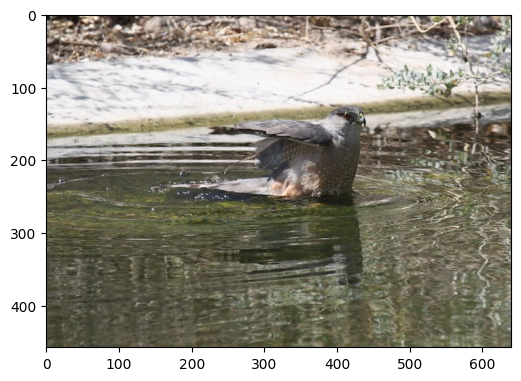

In [ ]:
import requests
from PIL import Image
from io import BytesIO

# Read image
url = 'http://farm4.staticflickr.com/3730/9455431370_d8b61be4e4_z.jpg'
# url = 'http://farm5.staticflickr.com/4095/4886266871_949e713af3_z.jpg'
# url = 'http://farm9.staticflickr.com/8040/7928721018_0b26a5b000_z.jpg'
byte_tensor = torch.frombuffer(requests.get(url).content, dtype=torch.uint8)
img = decode_image(byte_tensor)
pil_image = to_pil_image(img)

# Show image
plt.figure(figsize=(6,6))
plt.imshow(pil_image)
plt.show()

### Semantic Segmentation



1. Task overview:
  - Task input: an image
  - Task output: output resolution matches the input image size, indicating the pixel-wise classification result

2. Review PyTorch [documentation](https://pytorch.org/vision/0.20/models.html#semantic-segmentation) for semantic segmentation to choose a model:

  - Model architecture options: Select [FCN](https://pytorch.org/vision/0.20/models/fcn.html)
  - Pretrained weights: Select [`FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`](https://pytorch.org/vision/0.20/models/generated/torchvision.models.segmentation.fcn_resnet50.html#torchvision.models.segmentation.FCN_ResNet50_Weights)
  - These weights were trained on a subset of [COCO Dataset](https://cocodataset.org/#home), using the 20 categories present in the [Pascal VOC Dataset](http://host.robots.ox.ac.uk/pascal/VOC/voc2012/).

3. Adopt sample code and get the result:

Downloading: "https://download.pytorch.org/models/fcn_resnet50_coco-1167a1af.pth" to /root/.cache/torch/hub/checkpoints/fcn_resnet50_coco-1167a1af.pth


100%|██████████| 135M/135M [00:00<00:00, 187MB/s]


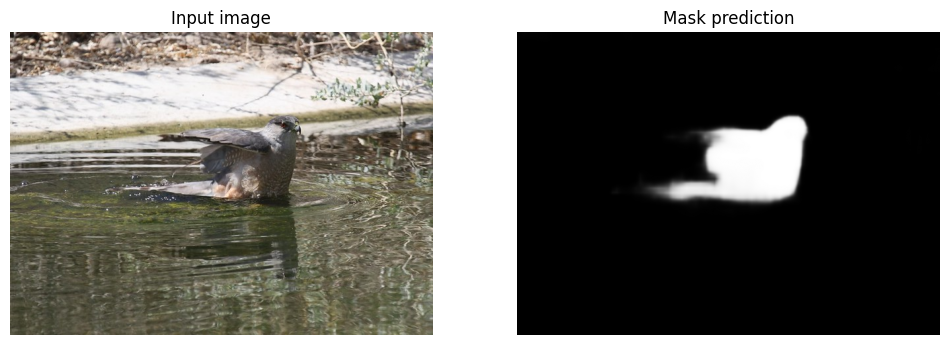

In [ ]:
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights

# Step 1: Initialize model with the best available weights
weights = FCN_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = fcn_resnet50(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

# Step 4: Pass image to the model and get output
prediction = model(batch)["out"]
normalized_masks = prediction.softmax(dim=1)

# Step 5: Process the output
class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}
mask = normalized_masks[0, class_to_idx["bird"]]
pil_mask = to_pil_image(mask)

# Step 6: Visualize result
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(pil_image)
axes[0].set_title("Input image")
axes[0].axis('off')
axes[1].imshow(pil_mask, cmap='gray')
axes[1].set_title("Mask prediction")
axes[1].axis('off')
plt.show()

4. Learn from the code:

   Typically, the output of semantic segmentation is in the format of `[batch_size, category_size, height, width]`. From the code, we see that the model returns a dictionary, where the prediction mask is grabbed from `["out"]`.
   ```
   prediction = model(batch)["out"]
   ```
   From the cell below, we can see the shape of the prediction map is `(1, 21, 520, 726)`. This tensor is in the format of pixel-wise multi-class classification output. Therefore, every pixel's final prediction is based on the softmax output of the second dimension (category_size):
   ```
   normalized_masks = prediction.softmax(dim=1)
   ```
   You might notice that the model is stated to be trained on 20 categories, but there are 21 categories here. This is because in semantic segmentation, the category "background" is typically automatically added, so there are $20 + 1 = 21$ categories in total.

   The category information is usually stored in `weights.meta["categories"]`. Therefore, by an index conversion, we can get the pixel-wise category prediction, which is why we use these lines to acquire the prediction mask:
   ```
   class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}
   mask = normalized_masks[0, class_to_idx["bird"]]
   ```

In [ ]:
print('Output prediction shape', prediction.shape)
print('All categories:\n', weights.meta["categories"])

Output prediction shape torch.Size([1, 21, 520, 726])
All categories:
 ['__background__', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


   For a complex model architecture packaged in `torchvision` (i.e., non-backbone models), we often can't apply `torchsummary.summary` directly. We instead can inspect the architecture with `print(model)`. Optionally, we are able to also summarize the model's submodules such as backbone structure.
   ```
   # backbone = model.backbone
   # summary(backbone, input_size=(image_size))
   ```
   However, the backbone structure **doens't include the entire model architecture**.

In [ ]:
# Print the entire model architecture
print('Model architecture:')
print(model)

# Summarize the backbone
# backbone = model.backbone
# summary(backbone, input_size=(3, 520, 520))

Model architecture:
FCN(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (d

### Object Detection



1. Task overview:
  - Task input: an image
  - Task output: bounding box(es) of detected objects

2. See PyTorch [documentation](https://pytorch.org/vision/0.20/models.html#object-detection) for object detection to choose a model:

  - Model architecture options: Select [Faster R-CNN](https://pytorch.org/vision/0.20/models/faster_rcnn.html)
  - Pretrained weights: Select [`FasterRCNN_ResNet50_FPN_V2_Weights`](https://pytorch.org/vision/0.20/models/generated/torchvision.models.detection.fasterrcnn_resnet50_fpn_v2.html#torchvision.models.detection.FasterRCNN_ResNet50_FPN_V2_Weights), which were trained on the [COCO Dataset](https://cocodataset.org/#home).


3. Adopt sample code and get the result:

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 198MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/utils.py:375: UserWarning: Argument 'font_size' will be ignored since 'font' is not set.
  warnings.warn("Argument 'font_size' will be ignored since 'font' is not set.")


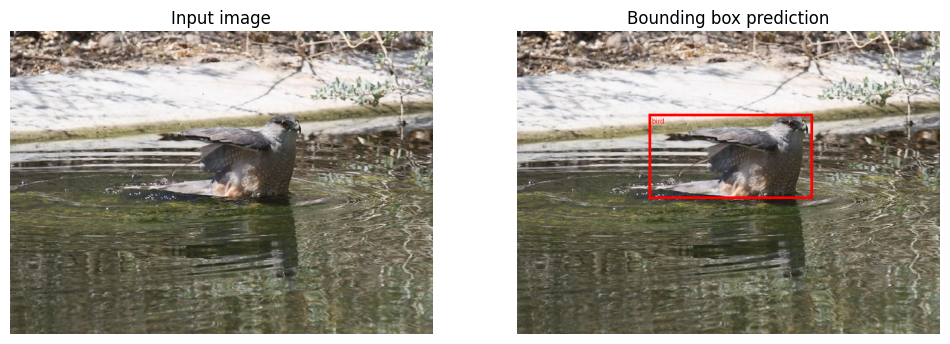

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes

# Step 1: Initialize model with the best available weights
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = [preprocess(img)]

# Step 4: Pass input data to the model
prediction = model(batch)[0]

# Step 5: Process output boxes and categories
labels = [weights.meta["categories"][i] for i in prediction["labels"]]
box = draw_bounding_boxes(img, boxes=prediction["boxes"],
                          labels=labels,
                          colors="red",
                          width=4, font_size=30)

# Step 6: Visualize results
img_bbox = to_pil_image(box.detach())
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(pil_image)
axes[0].set_title("Input image")
axes[0].axis('off')
axes[1].imshow(img_bbox, cmap='gray')
axes[1].set_title("Bounding box prediction")
axes[1].axis('off')
plt.show()

4. Learn from the code:

   First, let's print the entire prediction. There are three elements, `boxes`, `labels`, and `scores`. For every predicted bounding box, we can get the box coordinates from the stack of `prediction['boxes']` and it's category label from the stack of `prediction['labels']`.

   Similar to semantic segmentation, we are able to see the list of categories from `weights.meta['categories']`.

   Bounding boxes are typically stored using four elements:
   ```
   [xmin, ymin, xmax, ymax] or [xmin, ymin, width, height]
   ```
   From the function [`draw_bounding_boxes`](https://pytorch.org/vision/main/generated/torchvision.utils.draw_bounding_boxes.html), we learn that the output format should be `[xmin, ymin, xmax, ymax]`. Below, let's practicing unpacking and processing the result of the first prediction.

In [ ]:
print('Model prediction:\n', prediction)
print('All categories:\n', weights.meta['categories'])
print()

bbox = prediction['boxes'][0]
label_id = prediction['labels'][0]
print('First bounding box xmin: {:.2f}, ymin: {:.2f}, xmax: {:.2f}, ymax: {:.2f}'.format(bbox[0], bbox[1], bbox[2], bbox[3]))
print('First label id: {}, category name: {}'.format(label_id, weights.meta['categories'][label_id]))

Model prediction:
 {'boxes': tensor([[199.3400, 125.0722, 447.1501, 253.5237]], grad_fn=<StackBackward0>), 'labels': tensor([16]), 'scores': tensor([0.9963], grad_fn=<IndexBackward0>)}
All categories:
 ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cel

Similar to semantic segmentation, you are able to print the model architecture:

In [ ]:
# Print the entire model architecture
print('Model architecture:')
print(model)

Model architecture:
FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

### Instance Segmentation



1. Task overview:
  - Task input: an image
  - Task output: masks of detected objects

2. Review PyTorch [documentation](https://pytorch.org/vision/0.20/models.html#instance-segmentation) for object detection to choose model:

  - Model architecture options: Select [Mask R-CNN](https://pytorch.org/vision/0.20/models/mask_rcnn.html)
  - Pretrained weights: Select [`MaskRCNN_ResNet50_FPN_V2_Weights`](https://pytorch.org/vision/0.20/models/generated/torchvision.models.detection.maskrcnn_resnet50_fpn_v2.html#torchvision.models.detection.MaskRCNN_ResNet50_FPN_V2_Weights), which were trained on the [COCO Dataset](https://cocodataset.org/#home).

3. Adopt sample code and modify the visualization step following the [visualization tutorial](https://pytorch.org/vision/0.20/auto_examples/others/plot_visualization_utils.html#sphx-glr-auto-examples-others-plot-visualization-utils-py):

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_v2_coco-73cbd019.pth


100%|██████████| 177M/177M [00:01<00:00, 149MB/s]


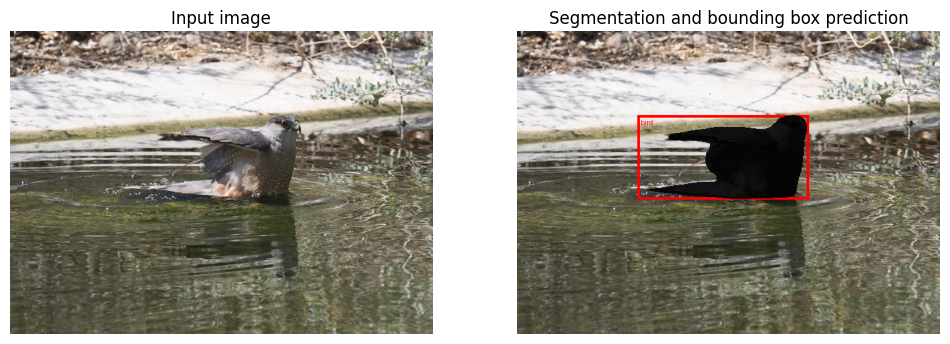

In [ ]:
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2, MaskRCNN_ResNet50_FPN_V2_Weights
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks

# Step 1: Initialize model with the best available weights
weights = MaskRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = maskrcnn_resnet50_fpn_v2(weights=weights, box_score_thresh=0.9)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = [preprocess(img)]

# Step 4: Pass input data to the model
prediction = model(batch)[0]

# Step 5: Process output boxes and categories
labels = [weights.meta["categories"][i] for i in prediction["labels"]]
box = draw_bounding_boxes(img, boxes=prediction["boxes"],
                          labels=labels,
                          colors="red",
                          width=4, font_size=30)
masks = prediction['masks']
bool_masks = masks > 0.5
bool_masks = bool_masks.squeeze(1)

# Step 6: Visualize results
img_masks = draw_segmentation_masks(box, bool_masks, alpha=0.9)
img_masks = to_pil_image(img_masks.detach())
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(pil_image)
axes[0].set_title("Input image")
axes[0].axis('off')
axes[1].imshow(img_masks)
axes[1].set_title("Segmentation and bounding box prediction")
axes[1].axis('off')
plt.show()

4. Learn from the code:
   
   Instance Segmentation results are similar to Object Detection results. In Mask R-CNN, the RoI area is further processed for a pixel-wise prediction to more accurately locate the object. The acquire the mask, we use:
   ```
   masks = prediction['masks']
   ```
   The format of masks results should be `[ object_size, 1, height, width]`, which are the pixel-wise predictions of the detected objects. In PyTorch, these masks are already converted into the size of the input image, so we can conveniently map the pixel-wise predictions to the input image.
   
   However, when using other libraries/modules, the output could be a mask that maps to the bounding box area. To process the raw output, bias and resizing need to be applied before visualization.

In [ ]:
print(len(weights.meta['categories']))
print('All categories:\n', weights.meta['categories'])
print(masks.shape)

91
All categories:
 ['__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']
torch.Size([1, 1, 458, 640])


Again, you can print the model architecture:

In [ ]:
print(model)

MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         

## Simple R-CNN with Pre-trained Classification Model's Backbone

In the previous tutorials, we have tried loading pretrained CNN models such as AlexNet and ResNet. In this tutorial, we will experiment using these classification models as the **pre-trained CNN backbones** for an **object detection model**.

### Object Detection Dataset

Before we start building the model, let's load a small object detection dataset. Follow this PyTorch [tutorial](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html) to load the **PennFudan** dataset.

When the output of a cell is too long, you can click the $\check{}$ symbol on the left side of the cell to fold the outputs.

In [ ]:
!wget https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip -P data
!cd data && unzip PennFudanPed.zip

--2026-02-03 04:14:32--  https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip
Resolving www.cis.upenn.edu (www.cis.upenn.edu)... 158.130.69.163, 2607:f470:8:64:5ea5::d
Connecting to www.cis.upenn.edu (www.cis.upenn.edu)|158.130.69.163|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53723336 (51M) [application/zip]
Saving to: ‘data/PennFudanPed.zip’

PennFudanPed.zip    100%[===================>]  51.23M  34.1MB/s    in 1.5s    

2026-02-03 04:14:34 (34.1 MB/s) - ‘data/PennFudanPed.zip’ saved [53723336/53723336]

Archive:  PennFudanPed.zip
   creating: PennFudanPed/
  inflating: PennFudanPed/added-object-list.txt  
   creating: PennFudanPed/Annotation/
  inflating: PennFudanPed/Annotation/FudanPed00001.txt  
  inflating: PennFudanPed/Annotation/FudanPed00002.txt  
  inflating: PennFudanPed/Annotation/FudanPed00003.txt  
  inflating: PennFudanPed/Annotation/FudanPed00004.txt  
  inflating: PennFudanPed/Annotation/FudanPed00005.txt  
  inflating: PennFudanPe

Following the PyTorch tutorial, visualize an image and its annotations. For object detection, we are also plotting the bounding boxes.

In [ ]:
# import the vision tools
import torchvision
from torchvision.ops import roi_align, box_iou, masks_to_boxes, nms
from torchvision.models import resnet18

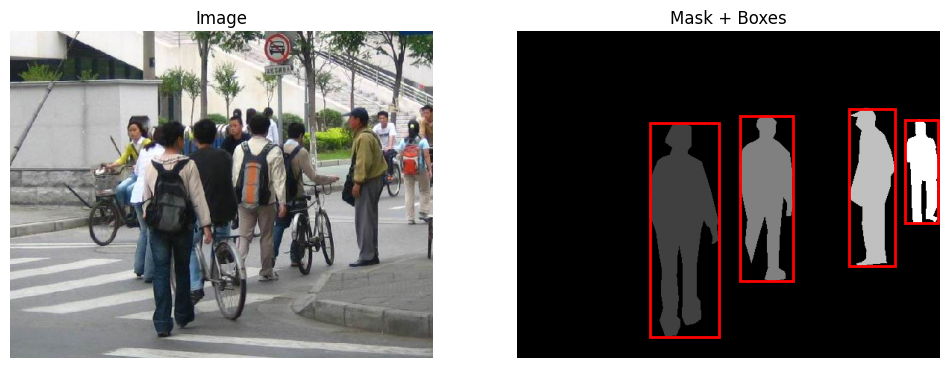

In [ ]:
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from torchvision.io import read_image

# Load
image = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
mask  = read_image("data/PennFudanPed/PedMasks/FudanPed00046_mask.png")[0]  # [H,W]

# Boxes from instance mask (IDs > 0)
obj_ids = torch.unique(mask)
obj_ids = obj_ids[obj_ids != 0]
boxes = [
    [xs.min().item(), ys.min().item(), xs.max().item(), ys.max().item()]
    for oid in obj_ids
    for ys, xs in [torch.where(mask == oid)]
]

# Plot: Image | Mask + boxes
plt.figure(figsize=(12, 8))

plt.subplot(121); plt.title("Image")
plt.imshow(image.permute(1, 2, 0)); plt.axis("off")

plt.subplot(122); plt.title("Mask + Boxes")
plt.imshow(mask, cmap="gray"); plt.axis("off")
ax = plt.gca()
for x1, y1, x2, y2 in boxes:
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor="red"))

plt.show()

With the downloaded dataset, we can build a class to hold the dataset following the PyTorch tutorial. Before applying the class, we need a function, `resize_image_and_boxes`, to **resize an image to a fixed resolution AND update its bounding boxes accordingly**.

Why do we need this?
- In our hand-built R-CNN, we stack images into a batch using `torch.stack(...)`.
- `torch.stack` requires every image in the batch to have the SAME H and W.
- PennFudan images have ***different sizes***, so we resize them to a fixed size.



In [ ]:
def resize_image_and_boxes(img, boxes, out_h=384, out_w=512):
    """
    img: Tensor [3,H,W] uint8 or float
    boxes: Tensor [N,4] XYXY in original image coords
    Returns resized img float32 [3,out_h,out_w] in [0,1] and scaled boxes.
    """
    C, H, W = img.shape
    img = img.float() / 255.0

    # Resize image
    img_resized = torch.nn.functional.interpolate(
        img.unsqueeze(0), size=(out_h, out_w), mode="bilinear", align_corners=False
    ).squeeze(0)

    if boxes.numel() == 0:
        return img_resized, boxes

    scale_x = out_w / float(W)
    scale_y = out_h / float(H)

    boxes_scaled = boxes.clone()
    boxes_scaled[:, 0] = boxes[:, 0] * scale_x
    boxes_scaled[:, 2] = boxes[:, 2] * scale_x
    boxes_scaled[:, 1] = boxes[:, 1] * scale_y
    boxes_scaled[:, 3] = boxes[:, 3] * scale_y

    return img_resized, boxes_scaled

In [ ]:
class PennFudanRCNNDataset(torch.utils.data.Dataset):
    def __init__(self, root="data/PennFudanPed", out_h=384, out_w=512):
        self.root = root
        self.out_h = out_h
        self.out_w = out_w
        self.imgs = sorted(os.listdir(os.path.join(root, "PNGImages")))
        self.masks = sorted(os.listdir(os.path.join(root, "PedMasks")))

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])

        img = read_image(img_path)        # [3,H,W] uint8
        mask = read_image(mask_path)[0]   # [H,W] uint8 (single channel is enough)

        # instance ids
        obj_ids = torch.unique(mask)
        obj_ids = obj_ids[obj_ids != 0]  # remove background id=0

        if len(obj_ids) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        else:
            masks = (mask[None, :, :] == obj_ids[:, None, None]).to(torch.uint8)  # [N,H,W]
            boxes = masks_to_boxes(masks)  # [N,4] XYXY

        # resize image + scale boxes
        img, boxes = resize_image_and_boxes(img, boxes, out_h=self.out_h, out_w=self.out_w)

        target = {"boxes": boxes, "labels": torch.ones((boxes.shape[0],), dtype=torch.int64)}
        return img, target

# create the collate_fn function for DataLoader
def collate_fn(batch):
    return tuple(zip(*batch))

Get ready for training:

In [ ]:
# Create dataset
dataset = PennFudanRCNNDataset(root="data/PennFudanPed", out_h=384, out_w=512)

# Split dataset
indices = torch.randperm(len(dataset)).tolist()
train_idx, test_idx = indices[:-50], indices[-50:]
train_ds = torch.utils.data.Subset(dataset, train_idx)
test_ds  = torch.utils.data.Subset(dataset, test_idx)

# Use data loader
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, collate_fn=collate_fn)
test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=2, collate_fn=collate_fn)

print("train:", len(train_ds), "test:", len(test_ds))

train: 120 test: 50


### Simple R-CNN Model

Following the R-CNN model architecture, we will build a similar model with simplified layers and fewer nodes. The components include:
- Region proposal & RoI Align*
- Class prediction head
- Bounding box regressor head

Before we code the model, `SimpleRCNN`, we need some functions to handle each of these components, such as handling proposals, classifications, and bounding boxes.

***Note**: This architecture is a mixture of the R-CNN and Faster R-CNN architectures. Please see the following details about this model
1. Instead of RoI Pooling, we use RoI Align. You can explore the torch tools for these modules via the following links: [`roi_algin`](https://docs.pytorch.org/vision/main/generated/torchvision.ops.roi_align.html), [`roi_pool`](https://docs.pytorch.org/vision/main/generated/torchvision.ops.roi_pool.html)
2. For simplicity, we use **region proposal** instead of **region proposal network (RPN).

#### Region Proposal



The original Faster R-CNN used a "Region Proposal Network" within the architecture to generate region proposals.  For simplicity, we instead generate random boxes. Generate random bounding boxes (`x1`, `y1`, `x2`, `y2`) within an image. We then label them using IoU with GT boxes.

In [ ]:
def generate_random_boxes(num_boxes, H, W, min_size=20, max_tries=5000, device="cpu"):
    boxes = []
    tries = 0
    # Keep sampling until we have enough boxes or we hit max_tries
    while len(boxes) < num_boxes and tries < max_tries:
        tries += 1

        # Pick top-left corner
        x1 = random.randint(0, max(0, W - 2))
        y1 = random.randint(0, max(0, H - 2))

        # Pick bottom-right corner (must be > top-left)
        x2 = random.randint(x1 + 1, W - 1)
        y2 = random.randint(y1 + 1, H - 1)

        # Reject boxes that are too small
        if (x2 - x1) >= min_size and (y2 - y1) >= min_size:
            boxes.append([x1, y1, x2, y2])

    if len(boxes) == 0:
        return torch.zeros((0, 4), dtype=torch.float32, device=device)
    return torch.tensor(boxes, dtype=torch.float32, device=device)


If we keep all proposals, the training batch can be huge and unstable. In fact, random proposals tend to be mostly negatives (background), which can dominate learning. Classic R-CNN training samples a fixed number of RoIs per image with a fixed positive fraction (e.g., 25% positives). Therefore, we will subsample proposals to a fixed batch size with a desired positive/negative ratio:

In [ ]:
def sample_pos_neg(proposals, labels, num_samples=128, pos_fraction=0.25):
    # Find indices of positive and negative examples
    pos_idx = torch.where(labels == 1)[0]
    neg_idx = torch.where(labels == 0)[0]

    # Desired counts (cap by how many we actually have)
    num_pos = min(int(num_samples * pos_fraction), pos_idx.numel())
    num_neg = min(num_samples - num_pos, neg_idx.numel())

    # Randomly pick positives
    if num_pos > 0:
        perm = torch.randperm(pos_idx.numel(), device=labels.device)[:num_pos]
        pos_keep = pos_idx[perm]
    else:
        pos_keep = pos_idx[:0]

    # Randomly pick negatives
    if num_neg > 0:
        perm = torch.randperm(neg_idx.numel(), device=labels.device)[:num_neg]
        neg_keep = neg_idx[perm]
    else:
        neg_keep = neg_idx[:0]

    # Return concatenated indices; (order doesn't matter much for training)
    keep = torch.cat([pos_keep, neg_keep], dim=0)
    return keep

#### Classification Head

Assign a label to each proposal based on IoU with GT boxes. This mimics classic R-CNN style training:
- Positive proposals: IoU >= `pos_iou`  -> label = `1` (person)
- Negative proposals: IoU <  `neg_iou`  -> label = `0` (background)
- Ambiguous proposals (in between):   -> label = `-1` (ignore, don't train on it)



In [ ]:
def label_proposals(proposals, gt_boxes, pos_iou=0.5, neg_iou=0.1):
    # If there are no proposals, return empty outputs
    if proposals.numel() == 0:
        return (
            torch.zeros((0,), dtype=torch.int64, device=proposals.device),
            torch.zeros((0, 4), dtype=torch.float32, device=proposals.device),
            torch.zeros((0,), dtype=torch.float32, device=proposals.device),
        )

    # If there are no GT boxes, every proposal is background (0)
    # Regression targets don't matter here, so matched_gt is all zeros.
    if gt_boxes.numel() == 0:
        labels = torch.zeros((proposals.shape[0],), dtype=torch.int64, device=proposals.device)
        matched_gt = torch.zeros_like(proposals)
        iou_max = torch.zeros((proposals.shape[0],), dtype=torch.float32, device=proposals.device)
        return labels, matched_gt, iou_max

    # Compute IoU between each proposal and each GT box: shape [N, M]
    ious = box_iou(proposals, gt_boxes)

    # For each proposal, find the best-matching GT (max IoU)
    iou_max, gt_idx = ious.max(dim=1)      # iou_max: [N], gt_idx: [N]
    matched_gt = gt_boxes[gt_idx]          # [N,4] best GT per proposal

    # Initialize all labels as "ignore"
    labels = torch.full((proposals.shape[0],), -1, dtype=torch.int64, device=proposals.device)

    # Assign positives / negatives
    labels[iou_max >= pos_iou] = 1
    labels[iou_max <  neg_iou] = 0

    return labels, matched_gt, iou_max

#### Bounding Box Regressor

Compute bounding box regression targets (deltas) that map proposals -> GT boxes. This is the classic R-CNN parameterization:
- Convert boxes to center + width/height
- Predict offsets:
  - dx = (gx - px)/pw
  - dy = (gy - py)/ph
  - dw = log(gw/pw)
  - dh = log(gh/ph)


In [ ]:
def encode_boxes(proposals, gt_boxes, eps=1e-6):
    # Unpack coords for proposals and GT
    px1, py1, px2, py2 = proposals.unbind(1)
    gx1, gy1, gx2, gy2 = gt_boxes.unbind(1)

    # Proposal width/height and center
    pw = (px2 - px1).clamp(min=eps)
    ph = (py2 - py1).clamp(min=eps)
    px = px1 + 0.5 * pw
    py = py1 + 0.5 * ph

    # GT width/height and center
    gw = (gx2 - gx1).clamp(min=eps)
    gh = (gy2 - gy1).clamp(min=eps)
    gx = gx1 + 0.5 * gw
    gy = gy1 + 0.5 * gh

    # Compute deltas (targets)
    dx = (gx - px) / pw
    dy = (gy - py) / ph
    dw = torch.log(gw / pw)
    dh = torch.log(gh / ph)

    return torch.stack([dx, dy, dw, dh], dim=1)

After the regressor head prediction, apply predicted deltas `(dx,dy,dw,dh)` to proposals to get refined boxes.


In [ ]:
def decode_boxes(proposals, deltas, eps=1e-6):
    px1, py1, px2, py2 = proposals.unbind(1)

    # proposal center/size
    pw = (px2 - px1).clamp(min=eps)
    ph = (py2 - py1).clamp(min=eps)
    px = px1 + 0.5 * pw
    py = py1 + 0.5 * ph

    # deltas
    dx, dy, dw, dh = deltas.unbind(1)

    # predicted center/size
    gx = px + dx * pw
    gy = py + dy * ph
    gw = pw * torch.exp(dw)
    gh = ph * torch.exp(dh)

    # convert back to XYXY
    x1 = gx - 0.5 * gw
    y1 = gy - 0.5 * gh
    x2 = gx + 0.5 * gw
    y2 = gy + 0.5 * gh

    return torch.stack([x1, y1, x2, y2], dim=1)

#### Create Model

This model includes:
- backbone (pre-trained `resnet18`)
- region proposal
- 2 heads

In the forwrd pass, R-CNN does the following:
1. Backbone CNN extracts a feature map for each image
2. For each proposal box (RoI), crop the corresponding region from the feature map and resize it to a fixed size
3. Feed each cropped RoI feature through a small MLP ("box head")
4. Predict:
   - class logits (background vs person)
   - box regression deltas (dx, dy, dw, dh)


In [ ]:
class SimpleRCNN(nn.Module):
    def __init__(self, freeze_backbone=True, roi_size=7, hidden_dim=256):
        super().__init__()
        backbone = resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])  # [B,512,H/32,W/32]
        self.out_channels = 512
        self.roi_size = roi_size

        # Use the pretrained backbone without training it
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        # Connect to output heads
        self.fc1 = nn.Linear(self.out_channels * roi_size * roi_size, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        # Create two heads for predictions
        self.cls_head = nn.Linear(hidden_dim, 2)  # classification: bg/person
        self.box_head = nn.Linear(hidden_dim, 4)  # class-agnostic bounding box deltas

    def forward(self, images, proposals):
        # 1. Batch the images and run the backbone
        x = torch.stack(images, dim=0) # [B, 3, H, W]
        feats = self.backbone(x)  # [B, C, Hf, Wf]
        B, C, Hf, Wf = feats.shape

        # 2. Build the ROI input format
        RoIs = []
        for b in range(B):
            # If an image happens to have no proposals, skip it.
            if proposals[b].numel() == 0:
                continue

            # Create a column vector filled with the image index b:
            batch_idx = torch.full(
                (proposals[b].shape[0], 1),
                b,
                device=feats.device
            )
            RoIs.append(torch.cat([batch_idx, proposals[b]], dim=1))

        # If there are no RoIs at all, return empty tensors (avoids crashing roi_align).
        if len(RoIs) == 0:
            return (
                torch.zeros((0, 2), device=feats.device),  # no class outputs
                torch.zeros((0, 4), device=feats.device),  # no box deltas
                feats
            )

        # Combine all images' RoIs into one big [K, 5] tensor
        RoIs = torch.cat(RoIs, dim=0)

        # 3. Crop each proposal region from the feature map
        spatial_scale = Wf / 512.0

        pooled = roi_align(
            feats, RoIs,
            output_size=(self.roi_size, self.roi_size),
            spatial_scale=spatial_scale,
            sampling_ratio=2,
            aligned=True
        )  # [K, C, roi, roi]

        # 4. Box head
        z = pooled.flatten(1)
        z = Fnn.relu(self.fc1(z))
        z = Fnn.relu(self.fc2(z))

        # 5. Classification head
        cls_logits = self.cls_head(z)
        box_deltas = self.box_head(z)

        return cls_logits, box_deltas

### Training

In this model, there are two losses to taken into account, `cls_loss` and `reg_loss`. To keep the training code clean, isolate the loss in a function:

In [ ]:
def rcnn_losses(cls_logits, box_deltas, labels, reg_targets):
    valid = labels != -1
    cls_loss = Fnn.cross_entropy(cls_logits[valid], labels[valid]) if valid.any() else cls_logits.sum() * 0.0
    pos = labels == 1
    reg_loss = Fnn.smooth_l1_loss(box_deltas[pos], reg_targets[pos], beta=1.0, reduction="mean") if pos.any() else box_deltas.sum() * 0.0
    return cls_loss, reg_loss

Similar to the training functions we've created before, write the training code that uses the assigned data and optimizer to train an assigned model.

Create a model and an optimizer:

In [ ]:
model = SimpleRCNN(freeze_backbone=True, roi_size=7, hidden_dim=256).to(device)

In [ ]:
# Only train parameters that require grad (backbone is frozen)
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, weight_decay=1e-4)

Start training:

In [ ]:
num_epochs   = 30
num_random   = 200   # random negative proposals per image
sample_k     = 128   # number of RoIs sampled per image (pos+neg)
pos_fraction = 0.25  # up to 25% positives among sampled RoIs

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0
    total_loss_cls = 0.0
    total_loss_reg = 0.0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        gt_boxes_list = [t["boxes"].to(device) for t in targets]

        # Build proposals for each image (GT + random negatives)
        proposals = []
        labels_list = []
        matched_gt_list = []

        for img, gt_boxes in zip(images, gt_boxes_list):
            C, H, W = img.shape

            # Generate random boxes to act as negative (background)
            rand = generate_random_boxes(num_random, H, W, min_size=20, device=device)

            # Concatenate GT boxes (good positives) + random boxes (mostly negatives)
            props = torch.cat([gt_boxes, rand], dim=0) if gt_boxes.numel() > 0 else rand

            # Label proposals by IoU
            labels, matched_gt, _ = label_proposals(props, gt_boxes, pos_iou=0.5, neg_iou=0.1)

            # Subsample proposals for stable training
            keep = sample_pos_neg(props, labels, num_samples=sample_k, pos_fraction=pos_fraction)

            props = props[keep]
            labels = labels[keep]
            matched_gt = matched_gt[keep]

            proposals.append(props)
            labels_list.append(labels)
            matched_gt_list.append(matched_gt)

        # Forward pass through our R-CNN
        cls_logits, box_deltas = model(images, proposals)

        # Prepare regression targets and compute losses
        labels_cat = torch.cat(labels_list, dim=0)          # [K]
        props_cat = torch.cat(proposals, dim=0)             # [K,4]
        matched_gt_cat = torch.cat(matched_gt_list, dim=0)  # [K,4]

        # Encode bbox deltas that map proposal
        reg_targets = encode_boxes(props_cat, matched_gt_cat)  # [K,4]

        # Combine the two losses
        cls_loss, reg_loss = rcnn_losses(cls_logits, box_deltas, labels_cat, reg_targets)
        loss = cls_loss + reg_loss

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_loss_cls += cls_loss.item()
        total_loss_reg += reg_loss.item()

    avg_loss = total_loss / max(1, len(train_loader))
    avg_loss_cls = total_loss_cls / max(1, len(train_loader))
    avg_loss_reg = total_loss_reg / max(1, len(train_loader))
    print(f"[Epoch {epoch+1}] total loss = {avg_loss:.4f} | cls = {avg_loss_cls:.4f} | reg = {avg_loss_reg:.4f}")

Epoch 1: total loss = 0.2112 | cls = 0.1780 | reg = 0.0331
Epoch 2: total loss = 0.0672 | cls = 0.0535 | reg = 0.0137
Epoch 3: total loss = 0.0626 | cls = 0.0493 | reg = 0.0133
Epoch 4: total loss = 0.0480 | cls = 0.0359 | reg = 0.0122
Epoch 5: total loss = 0.0497 | cls = 0.0374 | reg = 0.0123
Epoch 6: total loss = 0.0465 | cls = 0.0353 | reg = 0.0112
Epoch 7: total loss = 0.0336 | cls = 0.0228 | reg = 0.0108
Epoch 8: total loss = 0.0328 | cls = 0.0231 | reg = 0.0098
Epoch 9: total loss = 0.0411 | cls = 0.0295 | reg = 0.0116
Epoch 10: total loss = 0.0403 | cls = 0.0297 | reg = 0.0107
Epoch 11: total loss = 0.0273 | cls = 0.0191 | reg = 0.0082
Epoch 12: total loss = 0.0329 | cls = 0.0237 | reg = 0.0092
Epoch 13: total loss = 0.0259 | cls = 0.0171 | reg = 0.0088
Epoch 14: total loss = 0.0279 | cls = 0.0184 | reg = 0.0094
Epoch 15: total loss = 0.0238 | cls = 0.0152 | reg = 0.0087
Epoch 16: total loss = 0.0270 | cls = 0.0183 | reg = 0.0087
Epoch 17: total loss = 0.0262 | cls = 0.0179 | re

### Prediction

Let's use an image from the dataset and generate predictions using the trained model. Get an image and its ground truth:

In [ ]:
img_path  = "data/PennFudanPed/PNGImages/FudanPed00046.png"
mask_path = "data/PennFudanPed/PedMasks/FudanPed00046_mask.png"

image_raw = read_image(img_path)                 # [3,H,W] uint8
mask = read_image(mask_path)[0]                  # [H,W] uint8 (instance ids)

obj_ids = torch.unique(mask)
obj_ids = obj_ids[obj_ids != 0]
gt_boxes = torch.tensor(
    [
        [xs.min().item(), ys.min().item(), xs.max().item(), ys.max().item()]
        for oid in obj_ids
        for ys, xs in [torch.where(mask == oid)]
    ],
    dtype=torch.float32,
)

Preprocess the image the same way as training:

In [ ]:
img_resized, gt_boxes_scaled = resize_image_and_boxes(image_raw, gt_boxes, out_h=384, out_w=512)
img_resized = img_resized.to(device)

In [ ]:
model.eval()
with torch.no_grad():
    C, H, W = img_resized.shape
    proposals = generate_random_boxes(num_boxes=800, H=H, W=W, min_size=30, device=device)
    cls_logits, box_deltas = model([img_resized], [proposals])
    scores = torch.softmax(cls_logits, dim=1)[:, 1]
    pred_boxes = decode_boxes(proposals, box_deltas)

    # Clip boxes to image
    pred_boxes[:, 0::2] = pred_boxes[:, 0::2].clamp(0, W - 1)
    pred_boxes[:, 1::2] = pred_boxes[:, 1::2].clamp(0, H - 1)

    # Keep all boxes above a threshold
    score_thresh = 0.70
    keep = scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = scores[keep]

    # (Optional but recommended) NMS to reduce duplicates
    if pred_boxes.numel() > 0:
        keep_idx = torchvision.ops.nms(pred_boxes, pred_scores, iou_threshold=0.4)
        pred_boxes = pred_boxes[keep_idx]
        pred_scores = pred_scores[keep_idx]

Plot ground truth and prediction side-by-side:

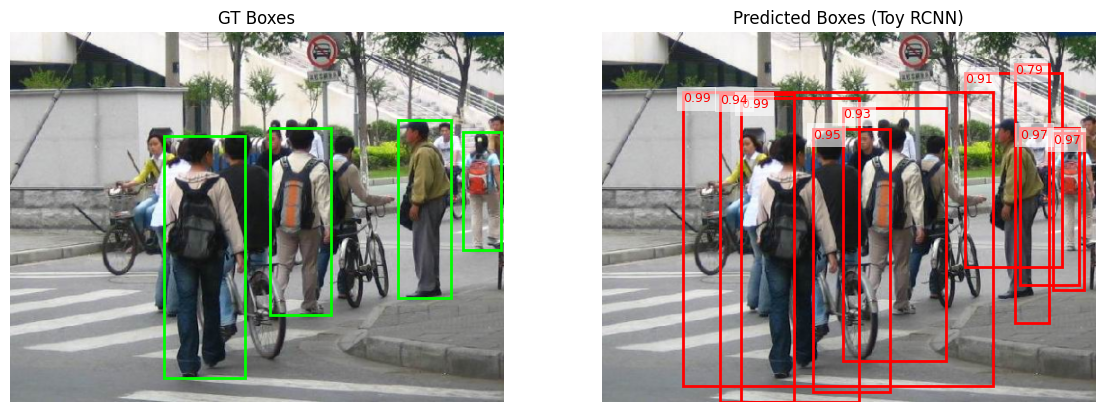

In [ ]:
import matplotlib.patches as patches

fig = plt.figure(figsize=(14, 8))

# Left: GT boxes on resized image
plt.subplot(121)
plt.title("GT Boxes")
plt.imshow(img_resized.permute(1, 2, 0).cpu())
plt.axis("off")
ax = plt.gca()
for x1, y1, x2, y2 in gt_boxes_scaled:
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor="lime"))

# Right: Predicted boxes on resized image
plt.subplot(122)
plt.title("Predicted Boxes (Toy R-CNN)")
plt.imshow(img_resized.permute(1, 2, 0).cpu())
plt.axis("off")
ax = plt.gca()
for (x1, y1, x2, y2), s in zip(pred_boxes.cpu(), pred_scores.cpu()):
    ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2, edgecolor="red"))
    ax.text(
        x1, y1, f"{s:.2f}",
        color="red", fontsize=9, va="top",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

plt.show()

## Review

When using a pretrained model to analyze images, there are various output types including index-to-category conversion, bounding boxes, and masks. Visualizing these prediction types can provide rich insight into a model's performance and help you debug.

Below are practice exercises you can try:
- Load a different image (i.e., use a different url in the second code cell) and run the three tasks to get prediction results.
- Load different localization models for each task and compare the results to the results above.

For any questions and discussions regarding this tutorial, attend [TA office hours](https://docs.google.com/spreadsheets/d/1abWD9DJqjEGrCdr8VbZ3aiOhx4vpT1y0-LOoLWgPwZM/edit?usp=sharing) or create a post on [Piazza](https://piazza.com/colorado/spring2026/csci49225922/home) :) See you in the next tutorial!

\- Everley